# RQ1: What is the expected flight delay based on its associated factors?

## Motivation

Often, when travelling, there are many unknown factors. The most crucial thing is the timing of
your transport and accommodation. By exploring this large
dataset full of information about flights, airports, weather
conditions, and delay times, we aim to find attributes, which
could be used to predict an expected delay time. We define
expected delay time in the statistical sense that it is the
mean delay time with its associated uncertainty. This could
be used to help travelers plan their accommodations and
transport accordingly, or for airlines/airports to anticipate
sources of delay and perhaps prevent them from occurring
in the first place.

## Proposed Methodology 

Using the dataset, we will perform
rounds of cleaning and encoding of information to create
useful and informative features for our model (i.e. one-hot
encoding for airline or airport). Then we will perform an
exploratory analysis to see if there are any patterns or trends
that we could leverage in our predictive model. Afterwards,
we will split the dataset into a training set and a test set for
model validation. We will start with baseline models (e.g.
linear regression, random forrest) and compare it with deep-
learning-based approaches to see if we get performance
gains. We expect there may be due to our large dataset and
find the complex relationships which underlie it, however,
if a simpler model can achieve similar performance, it is
preferrable due to its explainable nature.

In [1]:
# Import deps
import pandas as pd
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

In [2]:
files = glob("../data/flight-delay-dataset-20182022/Combined_Flights_*.parquet")
columns = [
    "FlightDate",
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "CRSDepTime",
    "CRSArrTime",
    "DepTimeBlk",
    "ArrTimeBlk",
    "Operating_Airline",
    "OriginAirportID",
    "DestAirportID",
    "Distance",
    "OriginAirportID",
    "DestAirportID",
    "OriginCityMarketID",
    "DestCityMarketID",
    "Distance",
    "DistanceGroup",
    "Marketing_Airline_Network",
    "Operating_Airline",
    "DOT_ID_Operating_Airline",
    "Tail_Number",
    "Flight_Number_Operating_Airline",
    "DepDelay",
    "ArrDelay"
]
df = pd.read_parquet(files, columns=columns, engine="pyarrow")

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 29193782 entries, 0 to 638648
Data columns (total 27 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   FlightDate                       datetime64[us]
 1   Year                             int64         
 2   Quarter                          int64         
 3   Month                            int64         
 4   DayofMonth                       int64         
 5   DayOfWeek                        int64         
 6   CRSDepTime                       int64         
 7   CRSArrTime                       int64         
 8   DepTimeBlk                       str           
 9   ArrTimeBlk                       str           
 10  Operating_Airline                str           
 11  OriginAirportID                  int64         
 12  DestAirportID                    int64         
 13  Distance                         float64       
 14  OriginAirportID                  int64         
 1

In [4]:
df.nunique()

FlightDate                         1673
Year                                  5
Quarter                               4
Month                                12
DayofMonth                           31
DayOfWeek                             7
CRSDepTime                         1425
CRSArrTime                         1440
DepTimeBlk                           19
ArrTimeBlk                           19
Operating_Airline                    28
OriginAirportID                     388
DestAirportID                       388
Distance                           1741
OriginAirportID                     388
DestAirportID                       388
OriginCityMarketID                  362
DestCityMarketID                    362
Distance                           1741
DistanceGroup                        11
Marketing_Airline_Network            11
Operating_Airline                    28
DOT_ID_Operating_Airline             28
Tail_Number                        7089
Flight_Number_Operating_Airline    7411


Text(0.5, 1.0, 'DepDelay Histogram  (1-99 Percentile)')

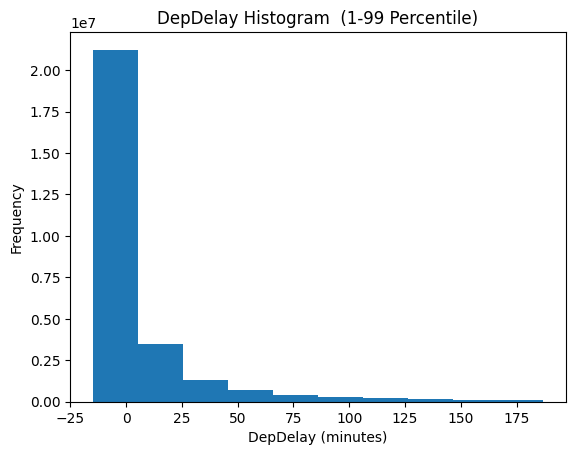

In [5]:
# Remove outliers
lower = df["DepDelay"].quantile(0.01)
upper = df["DepDelay"].quantile(0.99)
df = df[(df["DepDelay"] >= lower) & (df["DepDelay"] <= upper)]

# Check label distribution
plt.hist(df["DepDelay"])
plt.xlabel("DepDelay (minutes)")
plt.ylabel("Frequency")
plt.title("DepDelay Histogram  (1-99 Percentile)")

## Encoding the categoricals

In [6]:
# --- 1. Remove duplicated columns (present in your schema) ---
df = df.loc[:, ~df.columns.duplicated()]

# --- 2. Extract useful time features ---
df["dep_hour"] = df["CRSDepTime"] // 100
df["arr_hour"] = df["CRSArrTime"] // 100

df["week_of_year"] = df["FlightDate"].dt.isocalendar().week.astype("int16")
df["day_of_year"] = df["FlightDate"].dt.dayofyear.astype("int16")

# --- 3. Convert string categoricals to integer codes (memory efficient) ---
cat_cols = [
    "Operating_Airline",
    "Marketing_Airline_Network",
    "DepTimeBlk",
    "ArrTimeBlk",
    "Tail_Number"
]

for col in cat_cols:
    df[col] = df[col].astype("category").cat.codes.astype("int32")

# --- 4. Reduce numeric memory usage ---
df["Distance"] = df["Distance"].astype("float32")
df["DistanceGroup"] = df["DistanceGroup"].astype("int8")

df["OriginAirportID"] = df["OriginAirportID"].astype("int32")
df["DestAirportID"] = df["DestAirportID"].astype("int32")

df["OriginCityMarketID"] = df["OriginCityMarketID"].astype("int32")
df["DestCityMarketID"] = df["DestCityMarketID"].astype("int32")

df["DOT_ID_Operating_Airline"] = df["DOT_ID_Operating_Airline"].astype("int32")

# --- 5. Create route feature (very predictive) ---
df["route_id"] = (
    df["OriginAirportID"].astype("int64") * 100000 +
    df["DestAirportID"].astype("int64")
).astype("int64")

# --- 6. Optional: drop raw date to reduce memory ---
df = df.drop(columns=["FlightDate"])
df = df.dropna()

# --- 7. Frequency encoding (airport traffic intensity) ---
origin_freq = df["OriginAirportID"].value_counts()
dest_freq = df["DestAirportID"].value_counts()

df["origin_freq"] = df["OriginAirportID"].map(origin_freq).astype("int32")
df["dest_freq"] = df["DestAirportID"].map(dest_freq).astype("int32")


# --- 8. Target encoding (historical delay behavior) ---
# NOTE: assumes DepDelay and ArrDelay exist in df

origin_dep_delay = df.groupby("OriginAirportID")["DepDelay"].mean()
dest_arr_delay = df.groupby("DestAirportID")["ArrDelay"].mean()
airline_delay = df.groupby("Operating_Airline")["DepDelay"].mean()
route_delay = df.groupby("route_id")["ArrDelay"].mean()

df["origin_avg_dep_delay"] = df["OriginAirportID"].map(origin_dep_delay).astype("float32")
df["dest_avg_arr_delay"] = df["DestAirportID"].map(dest_arr_delay).astype("float32")
df["airline_avg_delay"] = df["Operating_Airline"].map(airline_delay).astype("float32")
df["route_avg_delay"] = df["route_id"].map(route_delay).astype("float32")


# --- 9. Optional: aircraft historical reliability ---
tail_delay = df.groupby("Tail_Number")["DepDelay"].mean()
df["tail_avg_delay"] = df["Tail_Number"].map(tail_delay).astype("float32")


# --- 10. Optional: drop raw ID columns if desired ---
drop_cols = [
    "OriginAirportID",
    "DestAirportID",
    "route_id",
    "Tail_Number"
]

df = df.drop(columns=drop_cols)
df = df.dropna()

print(df.info(memory_usage="deep"))

<class 'pandas.DataFrame'>
Index: 27866094 entries, 0 to 638648
Data columns (total 30 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Year                             int64  
 1   Quarter                          int64  
 2   Month                            int64  
 3   DayofMonth                       int64  
 4   DayOfWeek                        int64  
 5   CRSDepTime                       int64  
 6   CRSArrTime                       int64  
 7   DepTimeBlk                       int32  
 8   ArrTimeBlk                       int32  
 9   Operating_Airline                int32  
 10  Distance                         float32
 11  OriginCityMarketID               int32  
 12  DestCityMarketID                 int32  
 13  DistanceGroup                    int8   
 14  Marketing_Airline_Network        int32  
 15  DOT_ID_Operating_Airline         int32  
 16  Flight_Number_Operating_Airline  int64  
 17  DepDelay                

In [7]:
# Train-test split
# df = df.sample(frac=0.01) # test with 1% of the data
train = df[df["Year"] <= 2021]
test = df[df["Year"] == 2022]

## Regression Baseline

In [8]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

train = train.fillna(0)
test = test.fillna(0)

features = [
    "Year","Quarter","Month","DayofMonth","DayOfWeek",
    "dep_hour","arr_hour","week_of_year","day_of_year",
    "Distance","DistanceGroup",
    "origin_freq","dest_freq",
    "origin_avg_dep_delay","dest_avg_arr_delay",
    "airline_avg_delay","route_avg_delay","tail_avg_delay",
    "Operating_Airline","Marketing_Airline_Network",
    "DepTimeBlk","ArrTimeBlk"
]

y_train = train["DepDelay"]
y_test = test["DepDelay"]

scaler = StandardScaler()

X_train = scaler.fit_transform(train[features])
X_test = scaler.transform(test[features])

model = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=0.0001,
    max_iter=1000,
    learning_rate="adaptive"
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 15.31945158570888


## Dense-NN

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train = torch.tensor(train[features].values, dtype=torch.float32)
y_train = torch.tensor(train["DepDelay"].values, dtype=torch.float32).view(-1,1)

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=4096, shuffle=True)

class DelayModel(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = DelayModel(len(features)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.L1Loss()

Using device: cuda


  2%|▏         | 1/50 [03:39<2:59:04, 219.27s/it]

epoch loss: 1553075.867773056


  4%|▍         | 2/50 [07:13<2:53:11, 216.48s/it]

epoch loss: 113731.43742752075


  6%|▌         | 3/50 [10:47<2:48:25, 215.01s/it]

...

 98%|█████████▊| 49/50 [3:00:15<03:22, 202.70s/it]

epoch loss: 71210.64459609985


100%|██████████| 50/50 [3:03:33<00:00, 220.27s/it]

epoch loss: 71210.18149471283


Text(0, 0.5, 'L1 Loss')

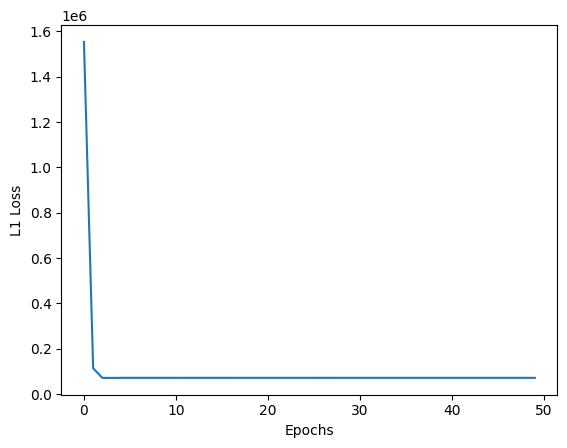

In [10]:
losses = []

for epoch in tqdm(range(50)):

    total_loss = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        pred = model(xb)

        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("epoch loss:", total_loss)
    losses.append(total_loss)

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("L1 Loss")

In [30]:
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

with torch.no_grad():
    pred = model(X_test_t).cpu().numpy()

from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, pred))

MAE: 14.869077730628243


Text(0, 0.5, 'Frequency')

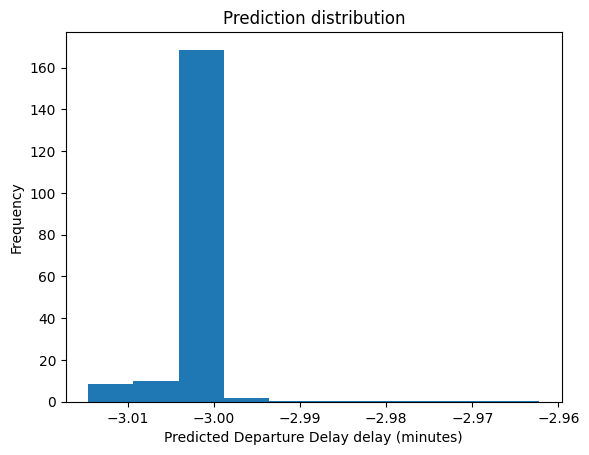

In [47]:
import numpy as np
preds_np = np.array(pred).flatten()

percentile_band = 0.05

lower = np.quantile(preds_np, percentile_band)
upper = np.quantile(preds_np, 1.0 - percentile_band)

preds_filtered = preds_np[(preds_np >= lower) & (preds_np <= upper)]

plt.hist(preds_filtered, density=True)
plt.title("Prediction distribution")
plt.xlabel("Predicted Departure Delay delay (minutes)")
plt.ylabel("Frequency")